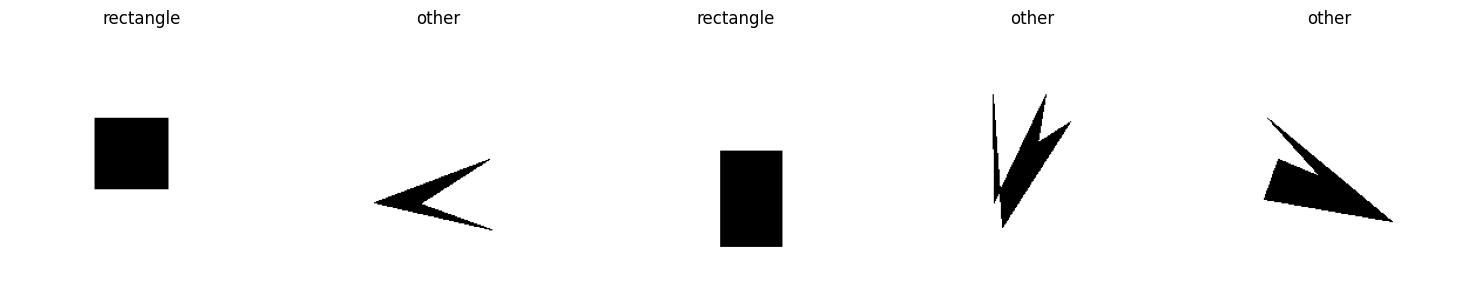

Shape of X: (10000, 224, 224, 1)
Shape of a single image: (224, 224, 1)


In [1]:
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def generate_synthetic_images(num_images, image_size, grayscale=False):
    images = []
    labels = []
    shapes = ['circle', 'rectangle', 'other']

    for _ in range(num_images):
        if grayscale:
            bg_color = np.random.randint(200, 256)
            img = np.full((image_size, image_size), bg_color, dtype=np.uint8)
            shape_color = np.random.randint(0, 200)
            while shape_color == bg_color:
                shape_color = np.random.randint(0, 200)
        else:
            bg_color = np.random.randint(200, 256, 3)
            img = np.full((image_size, image_size, 3), bg_color, dtype=np.uint8)
            shape_color = np.random.randint(0, 256, 3)
            while np.array_equal(shape_color, bg_color):
                shape_color = np.random.randint(0, 256, 3)

        shape = np.random.choice(shapes)

        if shape == 'circle':
            center = (np.random.randint(50, image_size-50), np.random.randint(50, image_size-50))
            radius = np.random.randint(20, 50)
            cv2.circle(img, center, radius, shape_color if grayscale else shape_color.tolist(), -1)
        elif shape == 'rectangle':
            x = np.random.randint(50, image_size-100)
            y = np.random.randint(50, image_size-100)
            width = np.random.randint(50, 100)
            height = np.random.randint(50, 100)
            cv2.rectangle(img, (x, y), (x+width, y+height), shape_color if grayscale else shape_color.tolist(), -1)
        else:
            points = np.random.rand(np.random.randint(3, 7), 2) * (image_size-100) + 50
            cv2.fillPoly(img, [points.astype(int)], shape_color if grayscale else shape_color.tolist())

        if grayscale:
            img = np.expand_dims(img, axis=-1)  # Add channel dimension for grayscale

        images.append(img)
        labels.append(shapes.index(shape))

    return np.array(images), np.array(labels)

# Generate datasets
num_images = 10000
image_size = 224
X, y = generate_synthetic_images(num_images, image_size, grayscale=True)

# Split the datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def display_images(images, labels, num_images=5, grayscale=False):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    shape_names = ['circle', 'rectangle', 'other']

    for i in range(num_images):
        if grayscale:
            axes[i].imshow(images[i].squeeze(), cmap='gray')  # Remove channel dimension for display
        else:
            axes[i].imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        axes[i].set_title(shape_names[labels[i]])
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Display 5 random grayscale images
random_indices = np.random.choice(len(X), 5, replace=False)
display_images(X[random_indices], y[random_indices], grayscale=True)

print("Shape of X:", X.shape)
print("Shape of a single image:", X[0].shape)

In [2]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Lambda
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import numpy as np

def build_model(input_shape, num_classes=3):
    model = Sequential()

    if input_shape[-1] == 1:  # Grayscale handling
        # Convert 1 channel to 3 channels using 1x1 convolution
        model.add(Conv2D(3, (1, 1), input_shape=input_shape))
        # Apply VGG16 preprocessing after channel conversion
        model.add(Lambda(preprocess_input))
    else:  # Color images handling
        # Apply preprocessing directly to 3-channel input
        model.add(Lambda(preprocess_input, input_shape=input_shape))

    # Base VGG16 model
    base_model = VGG16(weights='imagenet', include_top=False)
    base_model.trainable = False
    model.add(base_model)

    # Classifier layers
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    return model

def preprocess_images(images):
    # Only convert to float32, actual preprocessing is handled by model
    return images.astype('float32')

# Assuming X_train and X_test are your image datasets
input_shape = X_train.shape[1:]
num_classes = 3

# Preprocess data (only type conversion)
X_train_processed = preprocess_images(X_train)
X_test_processed = preprocess_images(X_test)

# Build and compile model
model = build_model(input_shape, num_classes)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train_processed, y_train, epochs=10, validation_split=0.2, batch_size=32)

# Evaluate the model
y_pred = model.predict(X_test_processed)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes, target_names=['circle', 'rectangle', 'other']))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 109s 420ms/step - accuracy: 0.9128 - loss: 1.1979 - val_accuracy: 0.9837 - val_loss: 0.0532
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 109s 366ms/step - accuracy: 0.9802 - loss: 0.1030 - val_accuracy: 0.9975 - val_loss: 0.0092
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 366ms/step - accuracy: 0.9882 - loss: 0.0514 - val_accuracy: 0.9950 - val_loss: 0.0160
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 366ms/step - accuracy: 0.9904 - loss: 0.0286 - val_accuracy: 0.9956 - val_loss: 0.0243
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 367ms/step - accuracy: 0.9878 - loss: 0.0617 - val_accuracy: 0.9981 - val_loss: 0.0043
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 357ms/step - accuracy: 0.9926 - loss: 0.0172 - val_accuracy: 0.9962 - val_loss: 0.0158
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 366ms/step - accuracy: 0.9894 - loss: 0.0309 - val_accuracy: 0.9981 - val_loss: 0.0052
Epoch 8/10
200/200 ━━━━━━━━━━━

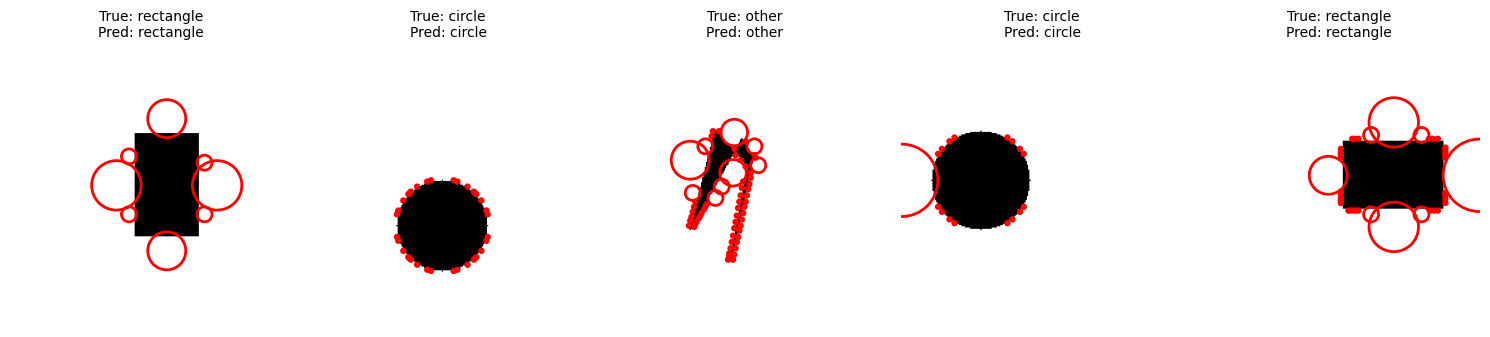

In [5]:
from skimage.feature import blob_log
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(images, true_labels, pred_labels, num_samples=5):
    shapes = ['circle', 'rectangle', 'other']  # Updated shape names
    plt.figure(figsize=(15, 10))

    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        img = images[i].squeeze()  # Remove the channel dimension for display

        # Display the grayscale image
        plt.imshow(img, cmap='gray')

        # Add ground truth and prediction labels
        true_shape = shapes[true_labels[i]]
        pred_shape = shapes[pred_labels[i]]
        plt.title(f"True: {true_shape}\nPred: {pred_shape}", fontsize=10)
        plt.axis('off')

        # Add blob detection overlay
        blobs = blob_log(img, max_sigma=30, num_sigma=10, threshold=.1)
        blobs[:, 2] = blobs[:, 2] * np.sqrt(2)  # Adjusting radii

        for blob in blobs:
            y, x, r = blob
            circle = plt.Circle((x, y), r, color='red', fill=False, linewidth=2)
            plt.gca().add_artist(circle)

    plt.tight_layout()
    plt.show()

# Select test samples and visualize predictions with updated labels
sample_indices = np.random.choice(len(X_test), 5, replace=False)
visualize_predictions(X_test,
                      y_test,
                      y_pred_classes,
                      num_samples=5)